Импортируем библиотеки:

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


Загружаем обработанный в предыдущей лабе датасет:

In [52]:
dataset = pd.read_csv("cirrhosis_preprocessed.csv")
dataset.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,58.805479
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,56.484932
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,70.120548
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,54.778082
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,38.131507


In [53]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             312 non-null    int64  
 1   N_Days         312 non-null    int64  
 2   Status         312 non-null    float64
 3   Drug           312 non-null    float64
 4   Age            312 non-null    int64  
 5   Sex            312 non-null    float64
 6   Ascites        312 non-null    float64
 7   Hepatomegaly   312 non-null    float64
 8   Spiders        312 non-null    float64
 9   Edema          312 non-null    float64
 10  Bilirubin      312 non-null    float64
 11  Cholesterol    312 non-null    float64
 12  Albumin        312 non-null    float64
 13  Copper         312 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  312 non-null    float64
 17  Platelets      312 non-null    float64
 18  Prothrombi

Проверим количество строк, которе принадлежит каждому классу:
0 -'C', 1 - 'CL', 2 - 'D'

In [54]:
dataset['Status'].value_counts()

,count
Status,
0.0,168
2.0,125
1.0,19


Уберем неинформативные столбцы:

In [55]:
dataset.drop(['ID', 'N_Days', 'Age_years', "Drug", ], axis=1, inplace=True)

Построим парный график:

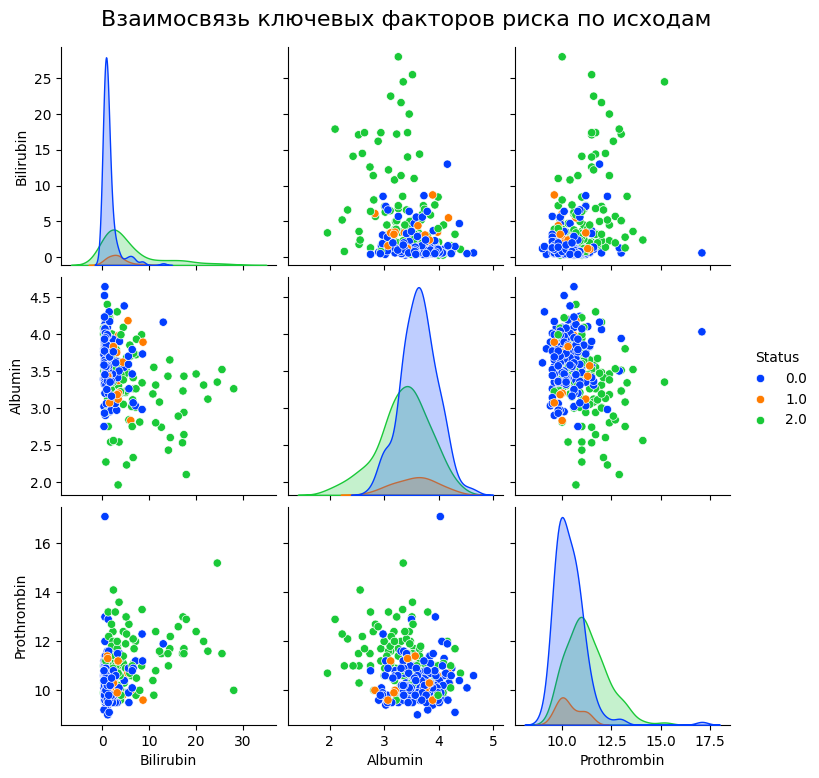

In [56]:
#Pairplot
g = sns.pairplot(dataset, vars=['Bilirubin', 'Albumin', 'Prothrombin'], hue='Status', palette='bright')

g.fig.suptitle('Взаимосвязь ключевых факторов риска по исходам', y=1.03, fontsize=16)

plt.show()

Для построения 2д графика на сырых (без понижения размерности данных) используем пару Bilirubin и Albumin

**Построение модели**

Разделение набора данных:

In [57]:
X = dataset.drop(['Status'], axis=1)
y = dataset['Status']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (312, 16) | y shape: (312,) 


In [58]:
y

,Status
0,2.0
1,0.0
2,2.0
3,2.0
4,1.0
...,...
307,0.0
308,0.0
309,0.0
310,0.0


Train Test разделение:

In [64]:
import scipy.stats as stats

y_mapped = y.map({0.0: 0, 1.0: 1, 2.0: 2})

X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.10, shuffle=True, stratify=y_mapped)

stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.07955495437258489), pvalue=np.float64(0.936642553210101), df=np.float64(310.0))

Выбор оптимальной модели:

In [65]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LR: 0.692857 (0.064286)
LDA: 0.710714 (0.082143)
KNN: 0.546429 (0.063987)
CART: 0.614286 (0.092857)
NB: 0.707143 (0.057143)
SVC: 0.539286 (0.010714)


LDA и NB показали наилучшие результаты.
Далее обучим LDA

In [67]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.875
sk LDA prediction: [2 2 0 2 0 0 2 0 0 0 0 2 0 2 0 2 0 2 0 0 0 0 0 0 2 2 0 2 0 0 0 0]
sk transformed features
[[-7.94831142 -6.09681071 -9.01994672 -8.38936858 -5.80186653]
 [-2.22423898 -4.4144974  -2.91744071 -3.82127506 -3.07384632]]


Мы увидели, что модель присвоила конкретные метки классов в prediction и перестроила фичи

# **Визуализация:**

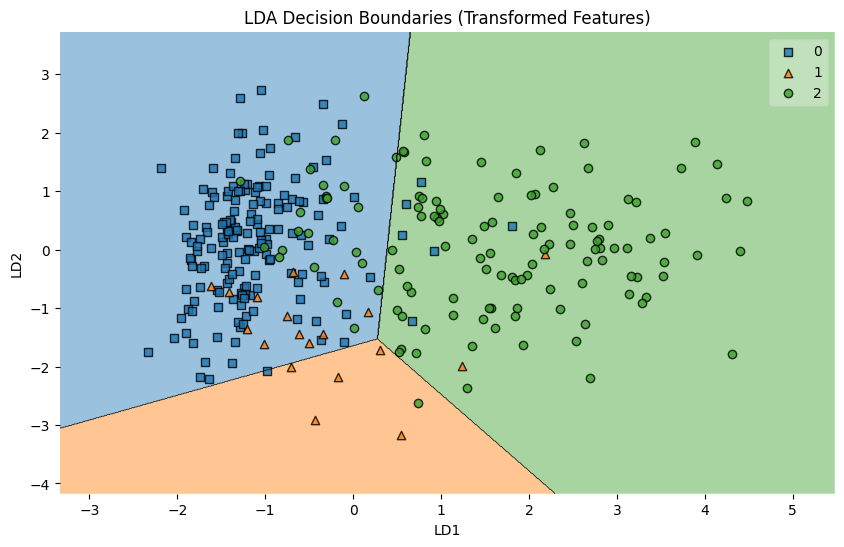

In [92]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split


X = dataset.drop(['Status'], axis=1)
df = dataset["Status"].map({0.0: 0, 1.0: 1, 2.0: 2})

sk_lda2 = LinearDiscriminantAnalysis(solver='svd')
X1_lda = sk_lda2.fit_transform(X, df)

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, df.values, random_state=0, stratify=df.values)


clf_visualizer = LinearDiscriminantAnalysis(solver='svd')
clf_visualizer.fit(X1_lda_train, y1_train)

plt.figure(figsize=(10, 6))
plot_decision_regions(X=X1_lda, y=df.values.astype(int), clf=clf_visualizer)
plt.title('LDA Decision Boundaries (Transformed Features)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()

#Проверяем модель на тестовых данных:

In [96]:
from sklearn import metrics
import numpy as np

# Используем модель, обученную на 2-х компонентах LDA
predicted = clf_visualizer.predict(X1_lda_test)
accuracy = metrics.accuracy_score(y1_test, predicted)

recall = metrics.recall_score(y1_test, predicted, average="weighted")
precision = metrics.precision_score(y1_test, predicted, average="weighted")

print(f"Accuracy: {round(accuracy, 2)}")
print(f"Recall: {round(recall, 2)}")
print(f"Precision: {round(precision, 2)}")
print("\nDetail:")
# Используем строковые метки классов для отчета
print(metrics.classification_report(y1_test, predicted, target_names=['C', 'CL', 'D']))

Accuracy: 0.83
Recall: 0.83
Precision: 0.86

Detail:
              precision    recall  f1-score   support

           C       0.78      1.00      0.88        42
          CL       1.00      0.20      0.33         5
           D       0.96      0.71      0.81        31

    accuracy                           0.83        78
   macro avg       0.91      0.64      0.67        78
weighted avg       0.86      0.83      0.82        78

